In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

import optuna

torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

/kaggle/input/datasets/chaitanyazunzurkar/fashion-mnist/fashion-mnist_test.csv
/kaggle/input/datasets/chaitanyazunzurkar/fashion-mnist/fashion-mnist_train.csv
2.10.0+cu128
12.8
True
Tesla T4


In [3]:
!pip install optuna

In [4]:
train = pd.read_csv('/kaggle/input/datasets/chaitanyazunzurkar/fashion-mnist/fashion-mnist_train.csv')
test = pd.read_csv('/kaggle/input/datasets/chaitanyazunzurkar/fashion-mnist/fashion-mnist_test.csv')

In [5]:
train.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
test.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
X_train = train.iloc[:, 1:].values
y_train = train.iloc[:, 0].values

X_test = test.iloc[:, 1:].values
y_test = test.iloc[:, 0].values

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

X_train_tensor, X_val_tensor, y_train_tensor, y_val_tensor = train_test_split(
    X_train_tensor,
    y_train_tensor,
    test_size=0.2,
    random_state=42
)

In [8]:
class CustomDataset(Dataset):
  def __init__(self, X, y):
    self.X = X
    self.y = y

  def __len__(self):
    return len(self.X)

  def __getitem__(self, index):
    return self.X[index], self.y[index]

In [9]:
train_dataset = CustomDataset(X_train_tensor, y_train_tensor)
val_dataset = CustomDataset(X_val_tensor, y_val_tensor)
test_dataset = CustomDataset(X_test_tensor, y_test_tensor)

In [32]:
class MyNN(nn.Module):
  def __init__(self, input_dim, output_dim, num_hidden_layer, neurons_per_layer, dropout_rate):
    super().__init__()
    layers = []

    for i in range(num_hidden_layer):
        layers.append(nn.Linear(input_dim, neurons_per_layer))
        layers.append(nn.BatchNorm1d(neurons_per_layer))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout_rate))
        input_dim = neurons_per_layer

    layers.append(nn.Linear(neurons_per_layer, output_dim))

    self.model = nn.Sequential(*layers)

  def forward(self, X):
    return self.model(X)

In [45]:
def objective(trial):
    
    best_loss = float('inf')
    patience = 10
    counter = 0
    
    train_loss_history = []
    val_loss_history = []
    
    train_acc_history = []
    val_acc_history = []
    
    # define a search space
    num_hidden_layer = trial.suggest_int(
        "num_hidden_layer",
        1,
        5
    )

    neurons_per_layer = trial.suggest_int(
        "neurons_per_layer", 
        8, 
        128, 
        step=8
    )

    epochs = trial.suggest_int("epochs", 10, 50, step=10)
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.2, 0.5)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])
    optimizer_name = trial.suggest_categorical(
        "optimizer",
        ["Adam", "SGD", "RMSprop"]
    )
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # model initalization 
    input_dim = 784
    output_dim = 10

    model = MyNN(input_dim, output_dim, num_hidden_layer, neurons_per_layer, dropout_rate)
    model = model.to(device)
    
    # parameter initalization 

    # optimizer selection
    loss_function = nn.CrossEntropyLoss()
    if optimizer_name == "Adam":
        optimizer = optim.Adam(
            model.parameters(), 
            lr=learning_rate,
            weight_decay=weight_decay
        )
    elif optimizer_name == "SGD":
        optimizer = optim.SGD(
            model.parameters(), 
            lr=learning_rate,
            weight_decay=weight_decay
        )
    elif optimizer_name == "RMSprop":
        optimizer = optim.RMSprop(
            model.parameters(), 
            lr=learning_rate,
            weight_decay=weight_decay
        )

    # training loop
    for epoch in range(epochs): 
    
        model.train() 
        train_loss = 0 
        train_correct = 0
        train_total = 0
        
        for X_batch, y_batch in train_loader: 
            
            X_batch = X_batch.float().to(device)
            y_batch = y_batch.to(device)
        
            y_pred = model(X_batch) 
    
            prediction = torch.argmax(
                y_pred,
                dim=1
            )

            train_correct += (y_batch == prediction).sum().item()
    
            train_total += y_batch.size(0)
            
            loss = loss_function(y_pred, y_batch)
        
            optimizer.zero_grad()
        
            loss.backward() 
        
            optimizer.step() 
        
            train_loss += loss.item() 


        model.eval()
    
        val_loss = 0
        val_correct = 0
        val_total = 0
    
        with torch.no_grad():
            
            for X_batch, y_batch in val_loader:
                
                X_batch = X_batch.float().to(device)
                y_batch = y_batch.to(device)
    
                y_pred = model(X_batch)
                predictions = torch.argmax(
                    y_pred,
                    dim=1
                )
                
                val_correct += (
                    predictions == y_batch
                ).sum().item()
                
                val_total += y_batch.size(0)
                loss = loss_function(y_pred, y_batch)
    
                val_loss += loss.item()


        train_loss = train_loss / len(train_loader)
        train_accuracy  = (train_correct / train_total)
        
        val_loss = val_loss / len(val_loader)
        val_accuracy = (val_correct / val_total)
    
        train_loss_history.append(
            train_loss
        )
        
        val_loss_history.append(
            val_loss
        )
        
        train_acc_history.append(
            train_accuracy
        )
        
        val_acc_history.append(
            val_accuracy
        )
        
        print(
            f'Epoch {epoch+1} | '
            f'Train Loss: {train_loss:.4f} | '
            f'Val Loss: {val_loss:.4f} | '
            f'Train Acc: {train_accuracy:.4f} | '
            f'Val Acc: {val_accuracy:.4f}'
        )
    
        if val_loss < best_loss: 
            best_loss = val_loss
            counter = 0
    
            torch.save(
                model.state_dict(),
                'best_model.pth'
            )
        else:
            counter += 1
            
            if counter >= patience: 
                print("\nEarly Stopping")
                break 

    # evaluation 
    model.eval() 

    correct = 0 
    total = 0 
    
    model.load_state_dict(
        torch.load(
            'best_model.pth'
        )
    )

    with torch.no_grad(): 
      for X_batch, y_batch in test_loader:
         
        X_batch = X_batch.float().to(device)
        y_batch = y_batch.to(device)
    
        y_pred = model(X_batch) 
    
        predictions = torch.argmax( y_pred, dim=1 ) 
    
        correct += ( predictions == y_batch ).sum().item() 
    
        total += y_batch.size(0) 
    
    accuracy = ( correct / total ) 
    
    return accuracy

In [46]:
study = optuna.create_study(direction='maximize')

[I 2026-06-12 07:05:35,786] A new study created in memory with name: no-name-6a4c6747-fe8a-460e-bcfb-d67f7b695a95


In [47]:
study.optimize(objective, n_trials=10)

Epoch 1 | Train Loss: 0.8796 | Val Loss: 0.5820 | Train Acc: 0.6943 | Val Acc: 0.7772
Epoch 2 | Train Loss: 0.7949 | Val Loss: 0.5314 | Train Acc: 0.7270 | Val Acc: 0.7962
Epoch 3 | Train Loss: 0.7877 | Val Loss: 0.5380 | Train Acc: 0.7318 | Val Acc: 0.8041
Epoch 4 | Train Loss: 0.7817 | Val Loss: 0.5390 | Train Acc: 0.7300 | Val Acc: 0.8050
Epoch 5 | Train Loss: 0.7868 | Val Loss: 0.5102 | Train Acc: 0.7300 | Val Acc: 0.8173
Epoch 6 | Train Loss: 0.7838 | Val Loss: 0.5202 | Train Acc: 0.7300 | Val Acc: 0.8166
Epoch 7 | Train Loss: 0.7809 | Val Loss: 0.5426 | Train Acc: 0.7303 | Val Acc: 0.8095
Epoch 8 | Train Loss: 0.7796 | Val Loss: 0.5583 | Train Acc: 0.7314 | Val Acc: 0.7999
Epoch 9 | Train Loss: 0.7838 | Val Loss: 0.5550 | Train Acc: 0.7300 | Val Acc: 0.7908
Epoch 10 | Train Loss: 0.7785 | Val Loss: 0.5187 | Train Acc: 0.7301 | Val Acc: 0.8187
Epoch 11 | Train Loss: 0.7829 | Val Loss: 0.5557 | Train Acc: 0.7283 | Val Acc: 0.7885
Epoch 12 | Train Loss: 0.7784 | Val Loss: 0.6114 | T

[I 2026-06-12 07:08:16,248] Trial 0 finished with value: 0.8187 and parameters: {'num_hidden_layer': 2, 'neurons_per_layer': 48, 'epochs': 40, 'learning_rate': 0.004172722742003803, 'dropout_rate': 0.4290773509663708, 'batch_size': 16, 'optimizer': 'RMSprop', 'weight_decay': 0.0005900973660511797}. Best is trial 0 with value: 0.8187.


Epoch 1 | Train Loss: 0.6846 | Val Loss: 0.4437 | Train Acc: 0.7618 | Val Acc: 0.8365
Epoch 2 | Train Loss: 0.5237 | Val Loss: 0.3832 | Train Acc: 0.8188 | Val Acc: 0.8572
Epoch 3 | Train Loss: 0.4745 | Val Loss: 0.3705 | Train Acc: 0.8333 | Val Acc: 0.8665
Epoch 4 | Train Loss: 0.4496 | Val Loss: 0.3522 | Train Acc: 0.8450 | Val Acc: 0.8678
Epoch 5 | Train Loss: 0.4323 | Val Loss: 0.3481 | Train Acc: 0.8502 | Val Acc: 0.8738
Epoch 6 | Train Loss: 0.4204 | Val Loss: 0.3429 | Train Acc: 0.8529 | Val Acc: 0.8755
Epoch 7 | Train Loss: 0.4022 | Val Loss: 0.3322 | Train Acc: 0.8605 | Val Acc: 0.8793
Epoch 8 | Train Loss: 0.3988 | Val Loss: 0.3214 | Train Acc: 0.8596 | Val Acc: 0.8843
Epoch 9 | Train Loss: 0.3885 | Val Loss: 0.3296 | Train Acc: 0.8649 | Val Acc: 0.8803
Epoch 10 | Train Loss: 0.3773 | Val Loss: 0.3272 | Train Acc: 0.8663 | Val Acc: 0.8808
Epoch 11 | Train Loss: 0.3722 | Val Loss: 0.3221 | Train Acc: 0.8706 | Val Acc: 0.8821
Epoch 12 | Train Loss: 0.3662 | Val Loss: 0.3432 | T

[I 2026-06-12 07:09:11,398] Trial 1 finished with value: 0.888 and parameters: {'num_hidden_layer': 4, 'neurons_per_layer': 120, 'epochs': 20, 'learning_rate': 0.001877405774725385, 'dropout_rate': 0.31797953583237, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 1.1653368669158656e-05}. Best is trial 1 with value: 0.888.


Epoch 1 | Train Loss: 1.9674 | Val Loss: 1.6407 | Train Acc: 0.3174 | Val Acc: 0.6869
Epoch 2 | Train Loss: 1.6387 | Val Loss: 1.3831 | Train Acc: 0.5207 | Val Acc: 0.7338
Epoch 3 | Train Loss: 1.4496 | Val Loss: 1.2295 | Train Acc: 0.6037 | Val Acc: 0.7413
Epoch 4 | Train Loss: 1.3091 | Val Loss: 1.0689 | Train Acc: 0.6442 | Val Acc: 0.7575
Epoch 5 | Train Loss: 1.1967 | Val Loss: 0.9485 | Train Acc: 0.6712 | Val Acc: 0.7683
Epoch 6 | Train Loss: 1.1047 | Val Loss: 0.8786 | Train Acc: 0.6929 | Val Acc: 0.7792
Epoch 7 | Train Loss: 1.0344 | Val Loss: 0.8161 | Train Acc: 0.7079 | Val Acc: 0.7837
Epoch 8 | Train Loss: 0.9715 | Val Loss: 0.7457 | Train Acc: 0.7181 | Val Acc: 0.7969
Epoch 9 | Train Loss: 0.9275 | Val Loss: 0.6933 | Train Acc: 0.7237 | Val Acc: 0.8041
Epoch 10 | Train Loss: 0.8860 | Val Loss: 0.6698 | Train Acc: 0.7370 | Val Acc: 0.8084
Epoch 11 | Train Loss: 0.8506 | Val Loss: 0.6260 | Train Acc: 0.7433 | Val Acc: 0.8125
Epoch 12 | Train Loss: 0.8245 | Val Loss: 0.6097 | T

...

[I 2026-06-12 07:17:50,455] Trial 7 finished with value: 0.5112 and parameters: {'num_hidden_layer': 4, 'neurons_per_layer': 16, 'epochs': 20, 'learning_rate': 0.03542527954313158, 'dropout_rate': 0.4713108125486145, 'batch_size': 16, 'optimizer': 'SGD', 'weight_decay': 1.2241444562290653e-05}. Best is trial 4 with value: 0.8924.


Epoch 1 | Train Loss: 0.7841 | Val Loss: 0.4721 | Train Acc: 0.7366 | Val Acc: 0.8252
Epoch 2 | Train Loss: 0.5904 | Val Loss: 0.4263 | Train Acc: 0.7994 | Val Acc: 0.8453
Epoch 3 | Train Loss: 0.5478 | Val Loss: 0.4042 | Train Acc: 0.8136 | Val Acc: 0.8495
Epoch 4 | Train Loss: 0.5150 | Val Loss: 0.4071 | Train Acc: 0.8254 | Val Acc: 0.8479
Epoch 5 | Train Loss: 0.4911 | Val Loss: 0.3912 | Train Acc: 0.8332 | Val Acc: 0.8597
Epoch 6 | Train Loss: 0.4783 | Val Loss: 0.3795 | Train Acc: 0.8366 | Val Acc: 0.8627
Epoch 7 | Train Loss: 0.4633 | Val Loss: 0.3703 | Train Acc: 0.8412 | Val Acc: 0.8638
Epoch 8 | Train Loss: 0.4571 | Val Loss: 0.3648 | Train Acc: 0.8449 | Val Acc: 0.8657
Epoch 9 | Train Loss: 0.4535 | Val Loss: 0.3609 | Train Acc: 0.8468 | Val Acc: 0.8656
Epoch 10 | Train Loss: 0.4428 | Val Loss: 0.3597 | Train Acc: 0.8499 | Val Acc: 0.8627
Epoch 11 | Train Loss: 0.4356 | Val Loss: 0.3641 | Train Acc: 0.8518 | Val Acc: 0.8670
Epoch 12 | Train Loss: 0.4295 | Val Loss: 0.3562 | T

[I 2026-06-12 07:18:34,681] Trial 8 finished with value: 0.8818 and parameters: {'num_hidden_layer': 3, 'neurons_per_layer': 88, 'epochs': 40, 'learning_rate': 0.0008315980258408026, 'dropout_rate': 0.44236523908940983, 'batch_size': 128, 'optimizer': 'RMSprop', 'weight_decay': 8.928499699630797e-05}. Best is trial 4 with value: 0.8924.


Epoch 33 | Train Loss: 0.3625 | Val Loss: 0.3295 | Train Acc: 0.8745 | Val Acc: 0.8821

Early Stopping
Epoch 1 | Train Loss: 2.2409 | Val Loss: 2.0319 | Train Acc: 0.1625 | Val Acc: 0.3916
Epoch 2 | Train Loss: 2.0898 | Val Loss: 1.9536 | Train Acc: 0.2239 | Val Acc: 0.4257
Epoch 3 | Train Loss: 1.9848 | Val Loss: 1.8357 | Train Acc: 0.2721 | Val Acc: 0.4611
Epoch 4 | Train Loss: 1.8952 | Val Loss: 1.6883 | Train Acc: 0.2981 | Val Acc: 0.4995
Epoch 5 | Train Loss: 1.8125 | Val Loss: 1.6123 | Train Acc: 0.3224 | Val Acc: 0.5214
Epoch 6 | Train Loss: 1.7603 | Val Loss: 1.5026 | Train Acc: 0.3330 | Val Acc: 0.5257
Epoch 7 | Train Loss: 1.7157 | Val Loss: 1.3861 | Train Acc: 0.3424 | Val Acc: 0.5166
Epoch 8 | Train Loss: 1.6729 | Val Loss: 1.3224 | Train Acc: 0.3535 | Val Acc: 0.5191
Epoch 9 | Train Loss: 1.6435 | Val Loss: 1.3206 | Train Acc: 0.3626 | Val Acc: 0.5147
Epoch 10 | Train Loss: 1.6141 | Val Loss: 1.2537 | Train Acc: 0.3676 | Val Acc: 0.5119


[I 2026-06-12 07:20:12,090] Trial 9 finished with value: 0.5115 and parameters: {'num_hidden_layer': 4, 'neurons_per_layer': 24, 'epochs': 10, 'learning_rate': 2.486631285395153e-05, 'dropout_rate': 0.43582781346707433, 'batch_size': 16, 'optimizer': 'Adam', 'weight_decay': 6.06497507870231e-05}. Best is trial 4 with value: 0.8924.


In [48]:
study.best_value

0.8924

In [57]:
best = study.best_params

In [52]:
best_loss = float('inf')
patience = 10
counter = 0

train_loss_history = []
val_loss_history = []

train_acc_history = []
val_acc_history = []

In [76]:
class Model(nn.Module):
  def __init__(self, features, num_hidden_layer, neurons_per_layer, dropout_rate):
      super().__init__()
      self.features = features
      layers = []
      input_dim = features
      

      for layer in range(num_hidden_layer):
          layers.append(nn.Linear(input_dim, neurons_per_layer))
          layers.append(nn.ReLU())
          layers.append(nn.BatchNorm1d(neurons_per_layer))
          layers.append(nn.Dropout(dropout_rate))

          input_dim = neurons_per_layer
    
      layers.append(nn.Linear(input_dim, 10))
          
      self.network = nn.Sequential(
          *layers
      )

  def forward(self, X):
    X = X.view(X.size(0), -1)
    return self.network(X)

In [77]:
model = Model(
    features=X_train_tensor.shape[1],
    num_hidden_layer=best["num_hidden_layer"],
    neurons_per_layer=best["neurons_per_layer"],
    dropout_rate=best["dropout_rate"]
)

model = model.to(device)

In [78]:
print(model)

Model(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=120, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(120, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.29485360853369547, inplace=False)
    (4): Linear(in_features=120, out_features=120, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(120, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.29485360853369547, inplace=False)
    (8): Linear(in_features=120, out_features=10, bias=True)
  )
)


In [83]:
optimizer = optim.Adam(
    model.parameters(),
    lr=best["learning_rate"],
    weight_decay=best["weight_decay"]
)

train_loader = DataLoader(train_dataset, batch_size=best["batch_size"], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=best["batch_size"], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=best["batch_size"], shuffle=False)
    
epochs = best["epochs"]

loss_function = nn.CrossEntropyLoss()

In [84]:
for epoch in range(epochs): 
    
    model.train() 
    train_loss = 0 
    train_correct = 0
    train_total = 0
    
    for X_batch, y_batch in train_loader: 
        
        X_batch = X_batch.float().to(device)
        y_batch = y_batch.to(device)
    
        y_pred = model(X_batch)

        prediction = torch.argmax(
            y_pred,
            dim=1
        )

        train_correct += (y_batch == prediction).sum().item()

        train_total += y_batch.size(0)
        
        loss = loss_function(y_pred, y_batch)
    
        optimizer.zero_grad()
    
        loss.backward() 
    
        optimizer.step() 
    
        train_loss += loss.item() 


    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        
        for X_batch, y_batch in val_loader:
            
            X_batch = X_batch.float().to(device)
            y_batch = y_batch.to(device)

            y_pred = model(X_batch)
            predictions = torch.argmax(
                y_pred,
                dim=1
            )
            
            val_correct += (
                predictions == y_batch
            ).sum().item()
            
            val_total += y_batch.size(0)
            loss = loss_function(y_pred, y_batch)

            val_loss += loss.item()


    train_loss = train_loss / len(train_loader)
    train_accuracy  = (train_correct / train_total)
    
    val_loss = val_loss / len(val_loader)
    val_accuracy = (val_correct / val_total)

    train_loss_history.append(
        train_loss
    )
    
    val_loss_history.append(
        val_loss
    )
    
    train_acc_history.append(
        train_accuracy
    )
    
    val_acc_history.append(
        val_accuracy
    )
        
    print(
        f'Epoch {epoch+1} | '
        f'Train Loss: {train_loss:.4f} | '
        f'Val Loss: {val_loss:.4f} | '
        f'Train Acc: {train_accuracy:.4f} | '
        f'Val Acc: {val_accuracy:.4f}'
    )

    if val_loss < best_loss: 
        best_loss = val_loss
        counter = 0

        torch.save(
            model.state_dict(),
            'best_model.pth'
        )
    else:
        counter += 1
        
        if counter >= patience: 
            print("\nEarly Stopping")
            break 

Epoch 1 | Train Loss: 0.4969 | Val Loss: 0.3949 | Train Acc: 0.8261 | Val Acc: 0.8533
Epoch 2 | Train Loss: 0.4551 | Val Loss: 0.3946 | Train Acc: 0.8370 | Val Acc: 0.8535
Epoch 3 | Train Loss: 0.4485 | Val Loss: 0.3739 | Train Acc: 0.8397 | Val Acc: 0.8620
Epoch 4 | Train Loss: 0.4344 | Val Loss: 0.3662 | Train Acc: 0.8452 | Val Acc: 0.8693
Epoch 5 | Train Loss: 0.4251 | Val Loss: 0.3612 | Train Acc: 0.8491 | Val Acc: 0.8694
Epoch 6 | Train Loss: 0.4162 | Val Loss: 0.3658 | Train Acc: 0.8518 | Val Acc: 0.8657
Epoch 7 | Train Loss: 0.4088 | Val Loss: 0.3535 | Train Acc: 0.8536 | Val Acc: 0.8699
Epoch 8 | Train Loss: 0.4029 | Val Loss: 0.3529 | Train Acc: 0.8545 | Val Acc: 0.8680
Epoch 9 | Train Loss: 0.3958 | Val Loss: 0.3464 | Train Acc: 0.8583 | Val Acc: 0.8728
Epoch 10 | Train Loss: 0.3838 | Val Loss: 0.3411 | Train Acc: 0.8618 | Val Acc: 0.8740
Epoch 11 | Train Loss: 0.3813 | Val Loss: 0.3410 | Train Acc: 0.8635 | Val Acc: 0.8757
Epoch 12 | Train Loss: 0.3831 | Val Loss: 0.3377 | T

In [85]:
model.eval() 

correct = 0 
total = 0 

model.load_state_dict(
    torch.load(
        'best_model.pth'
    )
)

with torch.no_grad(): 
  for X_batch, y_batch in test_loader:
     
    X_batch = X_batch.float().to(device)
    y_batch = y_batch.to(device)

    y_pred = model(X_batch) 

    predictions = torch.argmax( y_pred, dim=1 ) 

    correct += ( predictions == y_batch ).sum().item() 

    total += y_batch.size(0) 
    
accuracy = ( correct / total ) 
print( f'\nAccuracy: {accuracy*100:.2f}%')


Accuracy: 88.35%


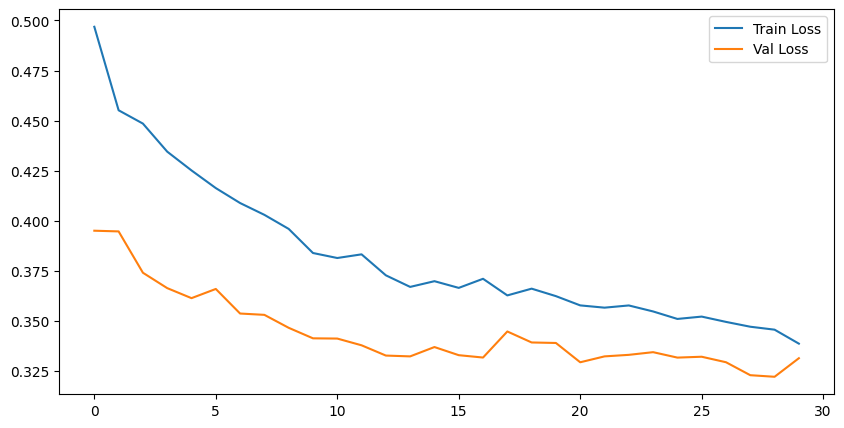

In [86]:
plt.figure(figsize=(10,5))

plt.plot(
    train_loss_history,
    label='Train Loss'
)

plt.plot(
    val_loss_history,
    label='Val Loss'
)

plt.legend()

plt.show()

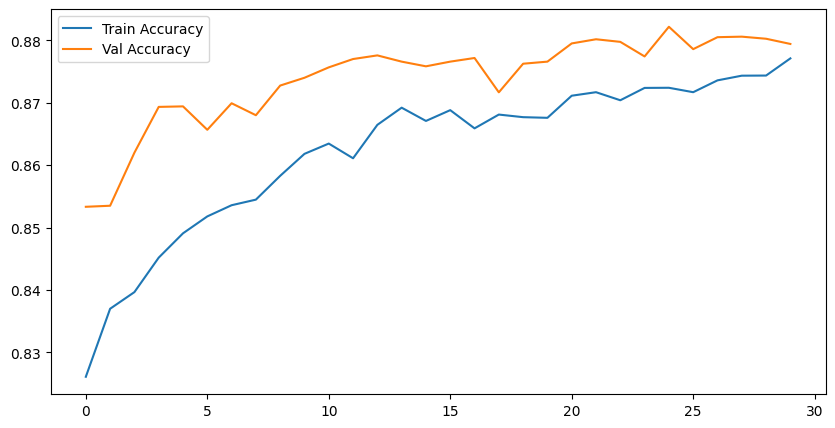

In [87]:
plt.figure(figsize=(10,5))

plt.plot(
    train_acc_history,
    label='Train Accuracy'
)

plt.plot(
    val_acc_history,
    label='Val Accuracy'
)

plt.legend()

plt.show()